In [28]:
!pip install deepchem rdkit -q

In [26]:
import os
from pathlib import Path

# Detect runtime environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Set project root based on environment
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/qsar-esol-solubility')
else:
    # Locally: notebook lives in notebooks/, project root is one level up
    PROJECT_ROOT = Path.cwd().parent

# Derived paths
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'

# Create directories if missing (helps when someone clones the repo)
for d in [RAW_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Colab
Project root: /content/drive/MyDrive/qsar-esol-solubility
Processed dir: /content/drive/MyDrive/qsar-esol-solubility/data/processed


In [29]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [30]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_delaney(
    featurizer='Raw',
    splitter='scaffold',
    transformers=[]   # no normalization
)
train, valid, test = datasets

print(f"Train: {len(train)}, Valid: {len(valid)}, Test: {len(test)}")

Train: 902, Valid: 113, Test: 113


In [31]:
import pandas as pd

def to_df(dataset):
    return pd.DataFrame({
        'smiles': dataset.ids,
        'logS': dataset.y.flatten()
    })

df_train = to_df(train)
df_valid = to_df(valid)
df_test  = to_df(test)

df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)
print(df_all.shape)
df_all.head()

(1128, 2)


,smiles,logS
0,CC(C)=CCCC(C)=CC(=O),-2.06
1,CCCC=C,-2.68
2,CCCCCCCCCCCCCC,-7.96
3,CC(C)Cl,-1.41
4,CCC(C)CO,-0.47


In [32]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

In [33]:
df_all['mol'] = df_all['smiles'].apply(Chem.MolFromSmiles)
n_invalid = df_all['mol'].isna().sum()

In [34]:
print(f'SMILES not parsable: {n_invalid}')
df = df_all[df_all['mol'].notna()].reset_index(drop=True)

SMILES not parsable: 0


In [37]:
# Canonical SMILES are the real and definitive ones. Mol From Smiles can generate different versions.
df_all['smiles_canonical'] = df_all['mol'].apply(Chem.MolToSmiles)
n_dup_raw = df_all['smiles'].duplicated().sum()
n_dup_canonical = df_all['smiles_canonical'].duplicated().sum()

In [38]:
print(f"Dup on raw SMILES : {n_dup_raw}")
print(f"Dup on canonical SMILES: {n_dup_canonical}")

Dup on raw SMILES : 0
Dup on canonical SMILES: 11


In [39]:
# Find all records that are part of a duplicate group (not just subsequent copies)
mask_dup = df_all['smiles_canonical'].duplicated(keep=False)
df_dups = df_all[mask_dup].sort_values('smiles_canonical')

print(f"Records involved in duplications: {len(df_dups)}")
print(df_dups[['smiles_canonical', 'logS']])

# Spread of logs within each group of duplicates
spread = df_dups.groupby('smiles_canonical')['logS'].agg(['min', 'max', 'mean', 'count'])
spread['delta'] = spread['max'] - spread['min']
print("\nSpread logS in duplicate groups:")
print(spread.sort_values('delta', ascending=False))

Records involved in duplications: 22
                            smiles_canonical   logS
617                         Brc1ccc2ccccc2c1 -4.400
622                         Brc1ccc2ccccc2c1 -4.400
913                    CC12CCC(CC1)C(C)(C)O2 -1.740
912                    CC12CCC(CC1)C(C)(C)O2 -1.640
909       CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O -4.402
908       CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O -4.160
647              CCC1(C(C)C)C(=O)NC(=O)NC1=O -2.148
644              CCC1(C(C)C)C(=O)NC(=O)NC1=O -2.210
646            CCC1(CCC(C)C)C(=O)NC(=O)NC1=O -2.658
633            CCC1(CCC(C)C)C(=O)NC(=O)NC1=O -2.468
861           CCC1(c2ccccc2)C(=O)NC(=O)NC1=O -2.322
862           CCC1(c2ccccc2)C(=O)NC(=O)NC1=O -2.322
805  CCOP(=S)(OCC)SC(CCl)N1C(=O)c2ccccc2C1=O -6.340
806  CCOP(=S)(OCC)SC(CCl)N1C(=O)c2ccccc2C1=O -6.340
559                              COc1ccccc1O -1.960
471                              COc1ccccc1O -1.960
878                Cc1ncc([N+](=O)[O-])n1CCO -1.220
879                Cc1ncc([

In [40]:
# Aggregate by canonical SMILES, averaging the logS of duplicates
df_dedup = (
    df_all
    .groupby('smiles_canonical', as_index=False)
    .agg(logS=('logS', 'mean'))
)

# Per ricostruire la colonna 'mol' (servirà più avanti)
df_dedup['mol'] = df_dedup['smiles_canonical'].apply(Chem.MolFromSmiles)

print(f"Dataset original: {len(df_all)}")
print(f"Dataset after dedup: {len(df_dedup)}")
print(f"Removed: {len(df_all) - len(df_dedup)}")
print("\nStatistiche logS after dedup:")
print(df_dedup['logS'].describe())

Dataset original: 1128
Dataset after dedup: 1117
Removed: 11

Statistiche logS after dedup:
count    1117.000000
mean       -3.050058
std         2.095457
min       -11.600000
25%        -4.310000
50%        -2.863000
75%        -1.600000
max         1.580000
Name: logS, dtype: float64


In [41]:
from rdkit.Chem import Descriptors, Crippen

df_dedup['MW']   = df_dedup['mol'].apply(Descriptors.MolWt)
df_dedup['LogP'] = df_dedup['mol'].apply(Crippen.MolLogP)

print(df_dedup[['MW', 'LogP']].describe())

                MW         LogP
count  1117.000000  1117.000000
mean    203.707382     2.453439
std     102.944082     1.845119
min      16.043000    -7.571400
25%     120.623000     1.417620
50%     182.172000     2.339200
75%     270.372000     3.391800
max     780.949000    10.388600


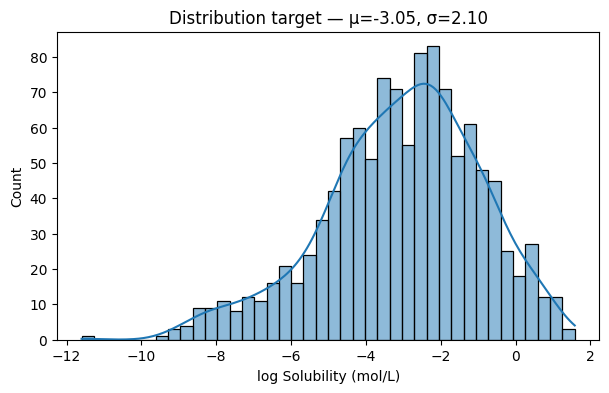

In [42]:
# 2. Target distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_all['logS'], bins=40, kde=True, ax=ax)
ax.set_xlabel('log Solubility (mol/L)')
ax.set_title(f"Distribution target — μ={df_all['logS'].mean():.2f}, σ={df_all['logS'].std():.2f}")
plt.show()

In [43]:
df_all['logS'].describe()

,logS
count,1128.000000
mean,-3.050102
std,2.096441
min,-11.600000
25%,-4.317500
50%,-2.860000
75%,-1.600000
max,1.580000


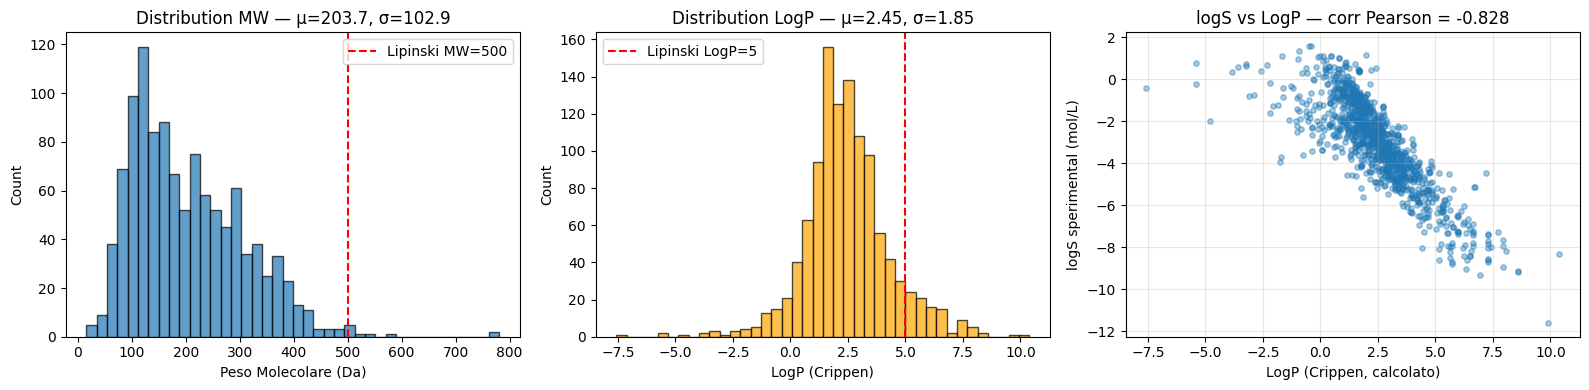

In [44]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) Istogramm MW
axes[0].hist(df_dedup['MW'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(500, color='red', linestyle='--', label='Lipinski MW=500')
axes[0].set_xlabel('Peso Molecolare (Da)')
axes[0].set_ylabel('Count')
axes[0].set_title(f"Distribution MW — μ={df_dedup['MW'].mean():.1f}, σ={df_dedup['MW'].std():.1f}")
axes[0].legend()

# (2) Istogramm LogP
axes[1].hist(df_dedup['LogP'], bins=40, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(5, color='red', linestyle='--', label='Lipinski LogP=5')
axes[1].set_xlabel('LogP (Crippen)')
axes[1].set_ylabel('Count')
axes[1].set_title(f"Distribution LogP — μ={df_dedup['LogP'].mean():.2f}, σ={df_dedup['LogP'].std():.2f}")
axes[1].legend()

# (3) Scatter logS vs LogP
axes[2].scatter(df_dedup['LogP'], df_dedup['logS'], alpha=0.4, s=15)
correlation = df_dedup[['LogP', 'logS']].corr().iloc[0, 1]
axes[2].set_xlabel('LogP (Crippen, calcolato)')
axes[2].set_ylabel('logS sperimental (mol/L)')
axes[2].set_title(f'logS vs LogP — corr Pearson = {correlation:.3f}')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Save dataset (only SMILES e logS)
df_to_save = df_dedup[['smiles_canonical', 'logS']].rename(columns={'smiles_canonical': 'smiles'})


In [46]:
output_path = PROCESSED_DIR / 'esol_dedup.csv'
df_to_save.to_csv(output_path, index=False)

print(f"Saved {len(df_to_save)} molecules to:")
print(output_path)
df_to_save.head()

Saved 1117 molecules to:
/content/drive/MyDrive/qsar-esol-solubility/data/processed/esol_dedup.csv


,smiles,logS
0,BrC(Br)(Br)Br,-3.14
1,BrC(Br)Br,-1.91
2,BrCBr,-1.17
3,BrCCBr,-1.68
4,Brc1cc(Br)c(Br)cc1Br,-6.98
